# FEATURE ENGINEERING Y ENTRENAMIENTO XGBOOST — VitalRisk AI
## Encabezado de contexto

Este notebook cubre HU12 (Feature Engineering + split temporal)
y HU13 (entrenamiento XGBoost).

**Decisión de split:** cronológico estricto para respetar la
dirección del tiempo en datos epidemiológicos semanales.
Train: 2018-2020 | Validation: 2021 | Test: 2022-2023

**Tipo de problema:** regresión (predecir casos_ira_total semana t+1)
**Modelo:** XGBoost Regressor con tree_method='hist' (nativo NaN)
**HUs que cierra:** HU12 + HU13
**Insumo:** fact_riesgo_territorial_ipt.csv (NB06)
**Output:** modelo_xgboost_vitalrisk.pkl + metricas_modelo.json

In [60]:
# %pip install xgboost

In [61]:
# ============================================================
# NOTEBOOK 07 — FEATURE ENGINEERING + ENTRENAMIENTO XGBOOST
# VitalRisk AI · Equipo 326
# HU12 (Feature Engineering + split temporal) + HU13 (XGBoost)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle, json, warnings
from pathlib import Path
from itertools import product
from collections import Counter
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression,
    RFECV, SelectFromModel
)
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

PROCESSED = Path("../data/processed")
MODELS    = Path("../data/models")
MODELS.mkdir(exist_ok=True)

In [62]:
df = pd.read_csv(PROCESSED / "fact_riesgo_territorial_ipt.csv",
                 dtype={'codigo_dane': str})
df['fecha_semana'] = pd.to_datetime(df['fecha_semana'])
print(f"Feature Store cargado: {df.shape}")
print(f"Rango: {df['anio'].min()} - {df['anio'].max()} | "
      f"Municipios: {df['codigo_dane'].nunique()}")

Feature Store cargado: (910, 36)
Rango: 2018 - 2023 | Municipios: 103


## 5. Entendimiento del Problema de Modelado

### 5.1 Tipo de problema y justificación del split
### 5.2 Construcción del target t+1 (sin leakage)
### 5.3 Definición del conjunto de features
### 5.4 Baseline naive — benchmark mínimo exigible

In [63]:
# ── 5.1 Tipo de problema y justificación del split ─────────
print("=== JUSTIFICACIÓN DEL SPLIT TEMPORAL ===\n")
print("Tipo de problema: REGRESIÓN (predecir casos_ira_total semana t+1)")
print("Métricas: RMSE, MAE, R²\n")
print("El split NO es aleatorio porque los datos tienen autocorrelación")
print("temporal fuerte (casos_ira_lag1 r=0.852 — NB05).")
print("Un split aleatorio produciría data leakage temporal:\n"
      "el modelo aprendería del futuro para predecir el pasado.\n")

=== JUSTIFICACIÓN DEL SPLIT TEMPORAL ===

Tipo de problema: REGRESIÓN (predecir casos_ira_total semana t+1)
Métricas: RMSE, MAE, R²

El split NO es aleatorio porque los datos tienen autocorrelación
temporal fuerte (casos_ira_lag1 r=0.852 — NB05).
Un split aleatorio produciría data leakage temporal:
el modelo aprendería del futuro para predecir el pasado.



In [64]:
dist = df.groupby('anio').size()
print("Distribución por año:")
print(dist.to_string())
print(f"\nSplit cronológico estricto:")
print(f"  Train     (2018-2020): {(df['anio']<=2020).sum():,} filas "
      f"({(df['anio']<=2020).mean()*100:.1f}%)")
print(f"  Val       (2021):      {(df['anio']==2021).sum():,} filas "
      f"({(df['anio']==2021).mean()*100:.1f}%)")
print(f"  Test      (2022-2023): {(df['anio']>=2022).sum():,} filas "
      f"({(df['anio']>=2022).mean()*100:.1f}%)")
print(f"\n  Nota epidemiológica: para datos de vigilancia en salud se")
print(f"  recomienda retener al menos 2 años como test (2022-2023)")
print(f"  para capturar la variabilidad post-pandemia.")

Distribución por año:
anio
2018    171
2019    250
2020    114
2021     53
2022    159
2023    163

Split cronológico estricto:
  Train     (2018-2020): 535 filas (58.8%)
  Val       (2021):      53 filas (5.8%)
  Test      (2022-2023): 322 filas (35.4%)

  Nota epidemiológica: para datos de vigilancia en salud se
  recomienda retener al menos 2 años como test (2022-2023)
  para capturar la variabilidad post-pandemia.


In [65]:
# ── 5.2 Construcción del target t+1 ───────────────────────
# El modelo predice casos_ira_total de la PRÓXIMA semana (t+1).
# Se desplaza la variable objetivo hacia adelante por municipio.
# La última semana de cada municipio no tiene t+1 → se elimina.

df = df.sort_values(['codigo_dane','anio','semana_epi']).reset_index(drop=True)
df['target_casos_t1'] = (
    df.groupby('codigo_dane')['casos_ira_total'].shift(-1)
)
df_model = df.dropna(subset=['target_casos_t1']).copy()
df_model['target_casos_t1'] = df_model['target_casos_t1'].astype(int)

print(f"Registros con target t+1: {len(df_model):,}")
print(f"(Eliminados: {len(df)-len(df_model)} — última semana por municipio)\n")
print("Distribución del target t+1:")
print(df_model['target_casos_t1'].describe().round(2))

Registros con target t+1: 807
(Eliminados: 103 — última semana por municipio)

Distribución del target t+1:
count    807.00
mean       3.16
std        3.37
min        1.00
25%        1.00
50%        1.00
75%        5.00
max       13.00
Name: target_casos_t1, dtype: float64


In [66]:
# ── 5.3 Definición del conjunto de features ────────────────
# Se excluyen explícitamente las siguientes columnas con justificación:

EXCLUIR = {
    'fecha_semana':               'info temporal redundante (ya está en anio+semana_epi)',
    'fuente_pm':                  'trazabilidad de origen, no predictiva',
    'nivel_riesgo':               'derivada del IPT — causaría leakage conceptual',
    'edad_promedio':              'Spearman=NaN en HU9 (varianza≈0 en municipios pequeños)',
    'icv_paredes':                'no significativa (p=0.195 en HU9)',
    'rezago_reporte_dias':        'no significativa (p=0.106 en HU9)',
    'subregion':                  'categórica string sin encoding — info ya en municipio_id',
    'poblacion_total':            'capturada en tasa_ira_100k (denominador)',
    'target_casos_t1':            'TARGET — no puede ser feature',
    'codigo_dane':                'reemplazada por municipio_id (numérica)',
}

In [67]:
print("=== VARIABLES EXCLUIDAS Y JUSTIFICACIÓN ===\n")
for col, razon in EXCLUIR.items():
    print(f"  ✗ {col}: {razon}")

# Encoding de codigo_dane como ID numérico categórico
df_model['municipio_id'] = df_model['codigo_dane'].astype('category').cat.codes

FEATURES_BASE = [
    col for col in df_model.columns
    if col not in list(EXCLUIR.keys()) + ['codigo_dane']
    and df_model[col].dtype in ['float64','int64','int32','Int64','bool']
]

print(f"\nFeatures base disponibles: {len(FEATURES_BASE)}")
for f in sorted(FEATURES_BASE):
    nulos = df_model[f].isna().mean()*100
    flag  = ' ⚠' if nulos > 30 else ''
    print(f"  {f}: {nulos:.1f}% nulos{flag}")

=== VARIABLES EXCLUIDAS Y JUSTIFICACIÓN ===

  ✗ fecha_semana: info temporal redundante (ya está en anio+semana_epi)
  ✗ fuente_pm: trazabilidad de origen, no predictiva
  ✗ nivel_riesgo: derivada del IPT — causaría leakage conceptual
  ✗ edad_promedio: Spearman=NaN en HU9 (varianza≈0 en municipios pequeños)
  ✗ icv_paredes: no significativa (p=0.195 en HU9)
  ✗ rezago_reporte_dias: no significativa (p=0.106 en HU9)
  ✗ subregion: categórica string sin encoding — info ya en municipio_id
  ✗ poblacion_total: capturada en tasa_ira_100k (denominador)
  ✗ target_casos_t1: TARGET — no puede ser feature
  ✗ codigo_dane: reemplazada por municipio_id (numérica)

Features base disponibles: 27
  anio: 0.0% nulos
  casos_ira_lag1: 9.7% nulos
  casos_ira_total: 0.0% nulos
  humedad_avg: 25.0% nulos
  icv_hacinamiento: 0.0% nulos
  icv_menores_6: 0.0% nulos
  icv_pisos: 0.0% nulos
  icv_score: 0.0% nulos
  icv_seg_social: 0.0% nulos
  ipm_pct: 0.0% nulos
  ipt_score: 0.0% nulos
  nbi: 0.0% nulos
  

In [68]:
# ── 5.4 Baseline naive ────────────────────────────────────
# Predecir que t+1 = t (persistencia de la semana actual).
# XGBoost debe superar este baseline — si no, el modelo no aporta.

rmse_naive = np.sqrt(mean_squared_error(
    df_model['target_casos_t1'], df_model['casos_ira_total']))
mae_naive  = mean_absolute_error(
    df_model['target_casos_t1'], df_model['casos_ira_total'])

print("=== BASELINE NAIVE (persistencia lag-1) ===")
print(f"  RMSE naive: {rmse_naive:.4f} casos/municipio-semana")
print(f"  MAE naive:  {mae_naive:.4f} casos/municipio-semana")
print(f"\n  Criterio HU14: RMSE_modelo < {rmse_naive:.2f}")
print(f"  Si el modelo no supera esto, aporta menos que predecir")
print(f"  'la próxima semana tendrá los mismos casos que esta'.")

=== BASELINE NAIVE (persistencia lag-1) ===
  RMSE naive: 2.0763 casos/municipio-semana
  MAE naive:  1.0768 casos/municipio-semana

  Criterio HU14: RMSE_modelo < 2.08
  Si el modelo no supera esto, aporta menos que predecir
  'la próxima semana tendrá los mismos casos que esta'.


## 6. Preparación de Datos y Feature Engineering

### 6.1 Feature Engineering — nuevas variables derivadas
### 6.2 Split cronológico train/validation/test
### 6.3 Funciones de evaluación para selección de features
### 6.4 Métodos de selección de features (estilo clase)
### 6.5 Tabla de estabilidad y selección final
### 6.6 Comparación PRE vs POST feature engineering

In [69]:
# ── 6.1 Feature Engineering ───────────────────────────────
# Nuevas features que capturan patrones sin introducir leakage.

# a) Estacionalidad trigonométrica
# Captura el patrón bimodal de IRA (picos semanas 10-15 y 35-45)
# sin tratar semana_epi como ordinal (semana 52 ≠ "mayor" que semana 1)
df_model['semana_sin'] = np.sin(2 * np.pi * df_model['semana_epi'] / 52)
df_model['semana_cos'] = np.cos(2 * np.pi * df_model['semana_epi'] / 52)

In [70]:
# b) Media histórica municipio×semana (solo desde train 2018-2020)
# Permite al modelo saber cuál es la línea base local para esa semana del año
media_hist = (
    df_model[df_model['anio'] <= 2020]
    .groupby(['codigo_dane','semana_epi'])['casos_ira_total']
    .mean().reset_index()
    .rename(columns={'casos_ira_total': 'media_hist_mun_sem'})
)
df_model = df_model.merge(media_hist, on=['codigo_dane','semana_epi'], how='left')

In [71]:
# Fallback: media global del municipio para municipios/semanas sin histórico
media_mun = (df_model[df_model['anio']<=2020]
             .groupby('codigo_dane')['casos_ira_total'].mean()
             .reset_index().rename(columns={'casos_ira_total':'media_mun_global'}))
df_model = df_model.merge(media_mun, on='codigo_dane', how='left')
df_model['media_hist_mun_sem'] = df_model['media_hist_mun_sem'].fillna(
    df_model['media_mun_global'])
df_model = df_model.drop(columns=['media_mun_global'])

In [72]:
# c) Desviación porcentual respecto al histórico
# Esta es la señal que activa las alertas en HU15
df_model['desviacion_vs_historico'] = np.where(
    df_model['media_hist_mun_sem'] > 0,
    (df_model['casos_ira_total'] - df_model['media_hist_mun_sem'])
    / df_model['media_hist_mun_sem'] * 100,
    0
)

print("Features de ingeniería generadas:")
print("  semana_sin, semana_cos → estacionalidad trigonométrica")
print("  media_hist_mun_sem     → benchmark local histórico (sin leakage)")
print("  desviacion_vs_historico→ señal de desviación para alertas HU15")
print(f"\nNulos nuevas features:")
print(f"  media_hist_mun_sem:     {df_model['media_hist_mun_sem'].isna().sum()}")
print(f"  desviacion_vs_historico:{df_model['desviacion_vs_historico'].isna().sum()}")

FEATURES_FE = FEATURES_BASE + [
    'semana_sin','semana_cos',
    'media_hist_mun_sem','desviacion_vs_historico'
]
FEATURES_FE = [f for f in FEATURES_FE if f in df_model.columns]
print(f"\nTotal features con FE: {len(FEATURES_FE)}")

Features de ingeniería generadas:
  semana_sin, semana_cos → estacionalidad trigonométrica
  media_hist_mun_sem     → benchmark local histórico (sin leakage)
  desviacion_vs_historico→ señal de desviación para alertas HU15

Nulos nuevas features:
  media_hist_mun_sem:     5
  desviacion_vs_historico:0

Total features con FE: 31


In [73]:
# ── 6.2 Split cronológico ─────────────────────────────────
mask_train = df_model['anio'] <= 2020
mask_val   = df_model['anio'] == 2021
mask_test  = df_model['anio'] >= 2022

In [74]:
X_train = df_model.loc[mask_train, FEATURES_FE].copy()
y_train = df_model.loc[mask_train, 'target_casos_t1'].copy()
X_val   = df_model.loc[mask_val,   FEATURES_FE].copy()
y_val   = df_model.loc[mask_val,   'target_casos_t1'].copy()
X_test  = df_model.loc[mask_test,  FEATURES_FE].copy()
y_test  = df_model.loc[mask_test,  'target_casos_t1'].copy()

# Para selección de features usamos subtrain/val (igual que en clase)
X_subtrain, y_subtrain = X_train, y_train

print("=== SPLIT CRONOLÓGICO ===")
print(f"  X_train:    {X_train.shape} | 2018-2020")
print(f"  X_val:      {X_val.shape}   | 2021")
print(f"  X_test:     {X_test.shape}  | 2022-2023")
print(f"\n  Pandemia en train: {df_model.loc[mask_train,'periodo_pandemia'].sum()} filas")
print(f"  Pandemia en val:   {df_model.loc[mask_val,'periodo_pandemia'].sum()} filas")
print(f"  Pandemia en test:  {df_model.loc[mask_test,'periodo_pandemia'].sum()} filas")

=== SPLIT CRONOLÓGICO ===
  X_train:    (498, 31) | 2018-2020
  X_val:      (53, 31)   | 2021
  X_test:     (256, 31)  | 2022-2023

  Pandemia en train: 61 filas
  Pandemia en val:   53 filas
  Pandemia en test:  0 filas


In [75]:
# ── 6.3 Funciones de evaluación (adaptadas de clase a REGRESIÓN) ──────
# En clase usabamos accuracy/F1 (clasificación).
# Aquí usamos RMSE/MAE/R² (regresión).

def modelo_evaluacion_rapido():
    """Modelo rápido para comparar subconjuntos de features en validación."""
    return GradientBoostingRegressor(
        n_estimators=50, max_depth=3,
        learning_rate=0.1, random_state=42
    )

def calcular_metricas_regresion(y_real, y_pred):
    y_r = np.asarray(y_real).ravel()
    y_p = np.asarray(y_pred).ravel()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_r, y_p))),
        'MAE':  float(mean_absolute_error(y_r, y_p)),
        'R2':   float(r2_score(y_r, y_p))
    }

def evaluar_features_en_validacion(features):
    feats_ok = [f for f in features if f in X_subtrain.columns]
    if not feats_ok:
        return {'RMSE': 999, 'MAE': 999, 'R2': -999}
    
    # Calcular mediana de imputación SOLO sobre subtrain (sin tocar val)
    fill_vals = X_subtrain[feats_ok].median()
    
    X_tr_f = X_subtrain[feats_ok].fillna(fill_vals)
    X_vl_f = X_val[feats_ok].fillna(fill_vals)  # imputa val con mediana de train
    
    pipe = Pipeline([('reg', modelo_evaluacion_rapido())])
    pipe.fit(X_tr_f, y_subtrain)
    pred = pipe.predict(X_vl_f)
    return calcular_metricas_regresion(y_val, pred)

def evaluar_features_en_test(features):
    feats_ok = [f for f in features if f in X_train.columns]
    if not feats_ok:
        return {'RMSE': 999, 'MAE': 999, 'R2': -999}
    
    X_trainval_f = pd.concat([X_train[feats_ok], X_val[feats_ok]])
    y_trainval_f = pd.concat([y_train, y_val])
    fill_vals    = X_trainval_f.median()
    
    X_trainval_f = X_trainval_f.fillna(fill_vals)
    X_test_f     = X_test[feats_ok].fillna(fill_vals)
    
    pipe = Pipeline([('reg', modelo_evaluacion_rapido())])
    pipe.fit(X_trainval_f, y_trainval_f)
    pred = pipe.predict(X_test_f)
    return calcular_metricas_regresion(y_test, pred)

def seleccionar_mejor_k_desde_ranking(nombre, ranking_features):
    """
    Igual que en clase: prueba añadir features una por una
    según el ranking y se queda con el k que minimiza RMSE en val.
    """
    filas = []
    for k in range(1, len(ranking_features) + 1):
        feats = list(ranking_features[:k])
        met   = evaluar_features_en_validacion(feats)
        filas.append({
            'Método': nombre, 'k': k, 'Rasgos': feats,
            'RMSE validación': met['RMSE'],
            'MAE validación':  met['MAE'],
            'R2 validación':   met['R2']
        })
    df_k   = pd.DataFrame(filas)
    mejor  = df_k.sort_values('RMSE validación').iloc[0]
    return list(mejor['Rasgos']), df_k

print("Funciones de evaluación definidas (adaptadas a regresión)")
print("  Métrica principal: RMSE (menor = mejor)")
print("  Métricas secundarias: MAE, R²")

Funciones de evaluación definidas (adaptadas a regresión)
  Métrica principal: RMSE (menor = mejor)
  Métricas secundarias: MAE, R²


In [76]:
# ── 6.4 Métodos de selección de features ──────────────────
# Igual que en clase: múltiples métodos, cada uno propone un ranking,
# se encuentra el mejor k para cada uno, y luego se vota por estabilidad.

feature_names = FEATURES_FE
feature_sets     = {}
curvas_validacion = {}

# ── LÍNEA BASE: todos los rasgos ──────────────────────────
feature_sets['Todos los rasgos'] = feature_names
print(f"\nEvaluando baseline: {len(feature_names)} features")


Evaluando baseline: 31 features


In [77]:
# ── 1. ANOVA F-test para regresión ────────────────────────
# Mide si la varianza entre grupos es mayor que dentro de grupos.
# Adaptado para regresión: f_regression en lugar de f_classif.
selector_anova = SelectKBest(score_func=f_regression, k='all')
selector_anova.fit(X_subtrain.fillna(X_subtrain.median()), y_subtrain)
anova_ranking = pd.Series(
    selector_anova.scores_, index=feature_names
).sort_values(ascending=False).index.tolist()

feature_sets['ANOVA F-test'], curvas_validacion['ANOVA F-test'] = \
    seleccionar_mejor_k_desde_ranking('ANOVA F-test', anova_ranking)
print(f"✓ ANOVA F-test: {len(feature_sets['ANOVA F-test'])} features seleccionadas")

✓ ANOVA F-test: 3 features seleccionadas


In [78]:
# ── 2. Información Mutua ──────────────────────────────────
# No asume distribución normal. Captura relaciones no lineales.
# Es más apropiado que ANOVA dado que las variables no son normales
# (Shapiro-Wilk p<0.001 — NB05).
mi_scores = mutual_info_regression(
    X_subtrain.fillna(X_subtrain.median()), y_subtrain, random_state=42
)
mi_ranking = pd.Series(
    mi_scores, index=feature_names
).sort_values(ascending=False).index.tolist()

feature_sets['Información Mutua'], curvas_validacion['Información Mutua'] = \
    seleccionar_mejor_k_desde_ranking('Información Mutua', mi_ranking)
print(f"✓ Información Mutua: {len(feature_sets['Información Mutua'])} features")

✓ Información Mutua: 15 features


In [79]:
# ── 3. Spearman Ranking (basado en correlaciones HU9) ─────
# Ya calculadas en NB05. Las reordenamos por |r| descendente.
# Este método es específico del proyecto — no es estándar de sklearn
# pero es el más justificado dado que Spearman fue validado en HU9.
corrs_spearman = {}
for col in feature_names:
    datos = df_model[[col,'target_casos_t1']].dropna()
    if len(datos) > 30:
        r, p = spearmanr(datos[col], datos['target_casos_t1'])
        corrs_spearman[col] = abs(r) if p < 0.05 else 0
    else:
        corrs_spearman[col] = 0

spearman_ranking = pd.Series(corrs_spearman).sort_values(
    ascending=False).index.tolist()

feature_sets['Spearman HU9'], curvas_validacion['Spearman HU9'] = \
    seleccionar_mejor_k_desde_ranking('Spearman HU9', spearman_ranking)
print(f"✓ Spearman HU9: {len(feature_sets['Spearman HU9'])} features")

✓ Spearman HU9: 3 features


In [80]:
# ── 4. L1 Embebido (Lasso) ────────────────────────────────
# La penalización L1 fuerza a cero los coeficientes de features
# irrelevantes. C en clasificación = alpha en regresión (inverso).
lasso = Lasso(alpha=0.1, max_iter=5000, random_state=42)
from sklearn.feature_selection import SelectFromModel
l1_selector = SelectFromModel(lasso, prefit=False)
l1_selector.fit(
    X_subtrain.fillna(X_subtrain.median()), y_subtrain)
feature_sets['L1 Lasso'] = [
    feature_names[i] for i, s
    in enumerate(l1_selector.get_support()) if s
]
print(f"✓ L1 Lasso: {len(feature_sets['L1 Lasso'])} features")

✓ L1 Lasso: 15 features


In [81]:
# ── 5. Random Forest Importance ───────────────────────────
# El RF calcula importancia por reducción de impureza (Gini/MSE).
# Más robusto que un solo árbol ante ruido.
rf = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_subtrain.fillna(X_subtrain.median()), y_subtrain)
rf_ranking = pd.Series(
    rf.feature_importances_, index=feature_names
).sort_values(ascending=False).index.tolist()

feature_sets['Random Forest'], curvas_validacion['Random Forest'] = \
    seleccionar_mejor_k_desde_ranking('Random Forest', rf_ranking)
print(f"✓ Random Forest: {len(feature_sets['Random Forest'])} features")

✓ Random Forest: 3 features


In [82]:
# ── 6. Gradient Boosting Importance ──────────────────────
# Igual que en clase. Usamos GradientBoostingRegressor.
# Al ser el modelo más parecido a XGBoost, este ranking es
# el más relevante para nuestro problema.
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_subtrain.fillna(X_subtrain.median()), y_subtrain)
gb_ranking = pd.Series(
    gb.feature_importances_, index=feature_names
).sort_values(ascending=False).index.tolist()

feature_sets['Gradient Boosting'], curvas_validacion['Gradient Boosting'] = \
    seleccionar_mejor_k_desde_ranking('Gradient Boosting', gb_ranking)
print(f"✓ Gradient Boosting: {len(feature_sets['Gradient Boosting'])} features")

✓ Gradient Boosting: 3 features


In [83]:
# ── 7. RFECV (costoso — elimina features iterativamente) ──
rfecv = RFECV(
    estimator=GradientBoostingRegressor(n_estimators=50, random_state=42),
    step=1,
    cv=KFold(n_splits=3, shuffle=False),  # KFold sin shuffle = respeta tiempo
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    min_features_to_select=3
)
rfecv.fit(X_subtrain.fillna(X_subtrain.median()), y_subtrain)
feature_sets['RFECV'] = [
    feature_names[i] for i, s
    in enumerate(rfecv.support_) if s
]
print(f"✓ RFECV: {len(feature_sets['RFECV'])} features (óptimo según CV)")

✓ RFECV: 19 features (óptimo según CV)


In [84]:
print(f"\n{'─'*60}")
print("Resumen de features seleccionadas por método:")
for metodo, feats in feature_sets.items():
    print(f"  {metodo}: {len(feats)} features")


────────────────────────────────────────────────────────────
Resumen de features seleccionadas por método:
  Todos los rasgos: 31 features
  ANOVA F-test: 3 features
  Información Mutua: 15 features
  Spearman HU9: 3 features
  L1 Lasso: 15 features
  Random Forest: 3 features
  Gradient Boosting: 3 features
  RFECV: 19 features


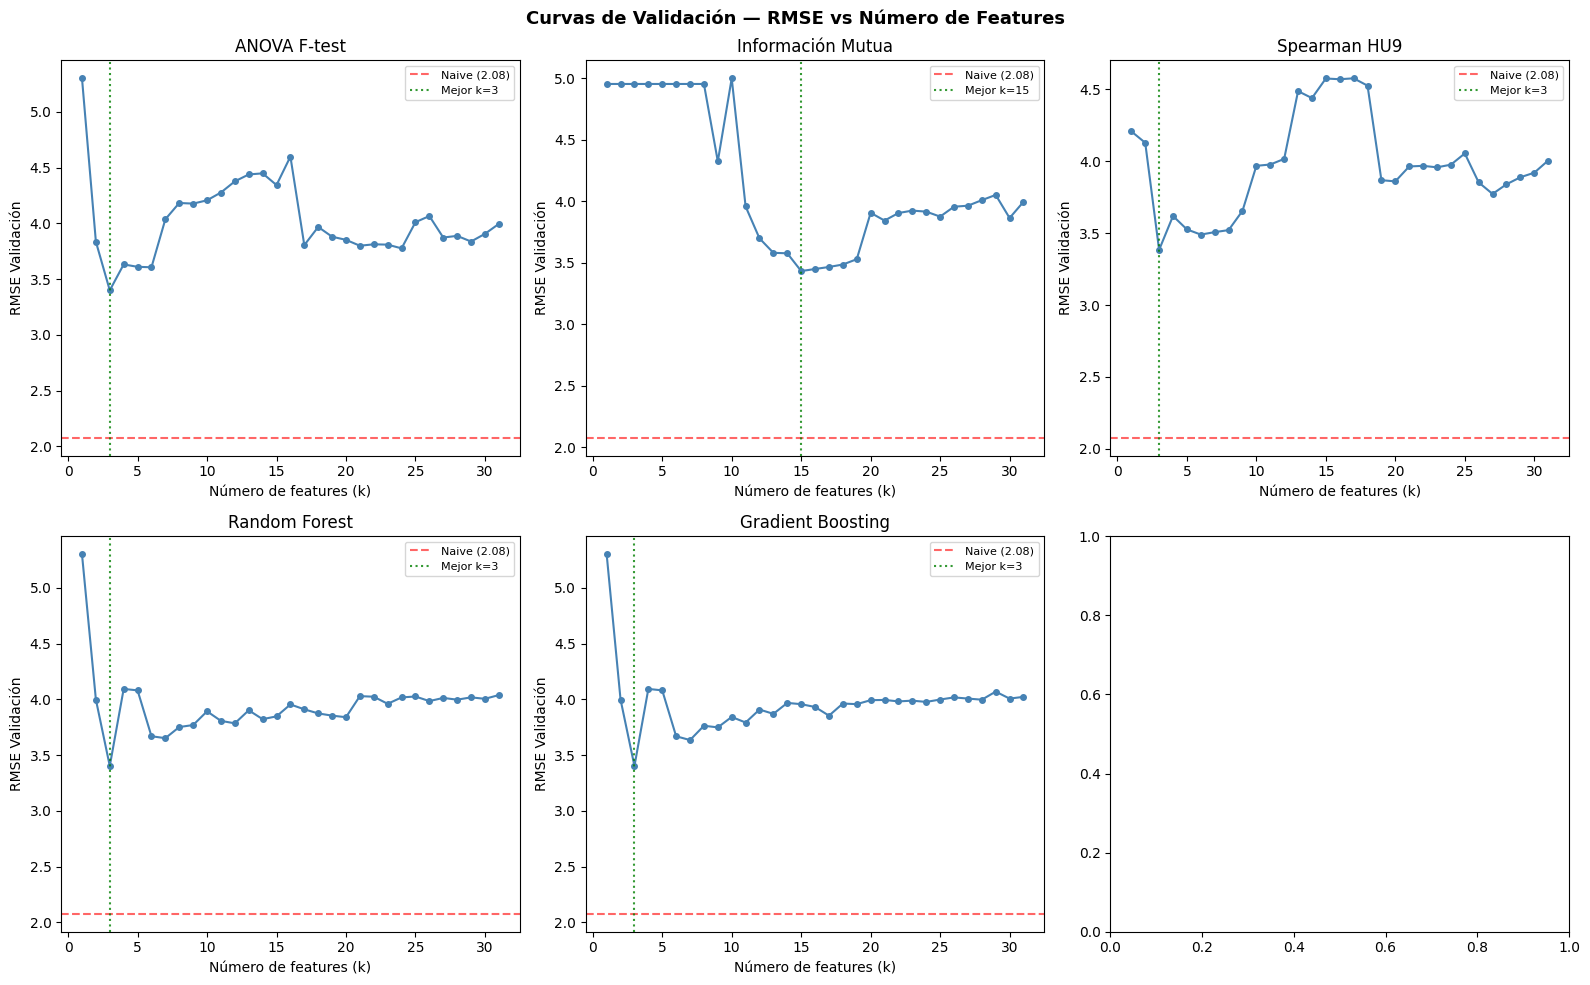

In [85]:
# ── Gráficas de curvas de validación (estilo clase) ────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas de Validación — RMSE vs Número de Features',
             fontsize=13, fontweight='bold')

metodos_con_curva = [m for m in curvas_validacion
                     if m in curvas_validacion]

for ax, metodo in zip(axes.flatten(), metodos_con_curva[:6]):
    df_k = curvas_validacion[metodo]
    ax.plot(df_k['k'], df_k['RMSE validación'],
            marker='o', markersize=4, color='steelblue')
    ax.axhline(y=rmse_naive, color='red', linestyle='--',
               alpha=0.6, label=f'Naive ({rmse_naive:.2f})')
    mejor_k = df_k.loc[df_k['RMSE validación'].idxmin()]
    ax.axvline(x=mejor_k['k'], color='green', linestyle=':',
               alpha=0.8, label=f"Mejor k={int(mejor_k['k'])}")
    ax.set_xlabel('Número de features (k)')
    ax.set_ylabel('RMSE Validación')
    ax.set_title(metodo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS / 'nb07_curvas_validacion_features.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [86]:
# ── 6.5 Tabla de estabilidad y selección final ────────────
# Igual que en clase: contar cuántos métodos seleccionan cada feature.
# Las features más estables (aparecen en más métodos) son las más confiables.

contador = Counter()
for metodo, feats in feature_sets.items():
    if metodo != 'Todos los rasgos':
        contador.update(feats)

estabilidad = (
    pd.DataFrame(contador.items(),
                 columns=['Feature', 'Métodos que la seleccionan'])
    .sort_values('Métodos que la seleccionan', ascending=False)
    .reset_index(drop=True)
)

In [87]:
print("=== TABLA DE ESTABILIDAD DE FEATURES ===\n")
print(estabilidad.to_string(index=False))

n_metodos = len([m for m in feature_sets if m != 'Todos los rasgos'])
print(f"\nTotal de métodos (sin 'Todos'): {n_metodos}")
print(f"Features seleccionadas por TODOS los métodos: "
      f"{(estabilidad['Métodos que la seleccionan']==n_metodos).sum()}")
print(f"Features seleccionadas por ≥ mitad de métodos: "
      f"{(estabilidad['Métodos que la seleccionan']>=n_metodos/2).sum()}")

=== TABLA DE ESTABILIDAD DE FEATURES ===

                       Feature  Métodos que la seleccionan
            media_hist_mun_sem                           7
               casos_ira_total                           7
                casos_ira_lag1                           7
                   humedad_avg                           3
       desviacion_vs_historico                           3
                           nbi                           2
                       ipm_pct                           2
        pct_regimen_subsidiado                           2
                 tasa_ira_100k                           2
                      pm25_avg                           2
                    semana_epi                           2
                   presion_avg                           2
                     pm25_lag1                           2
                     pm25_lag2                           2
                     ipt_score                           2
              

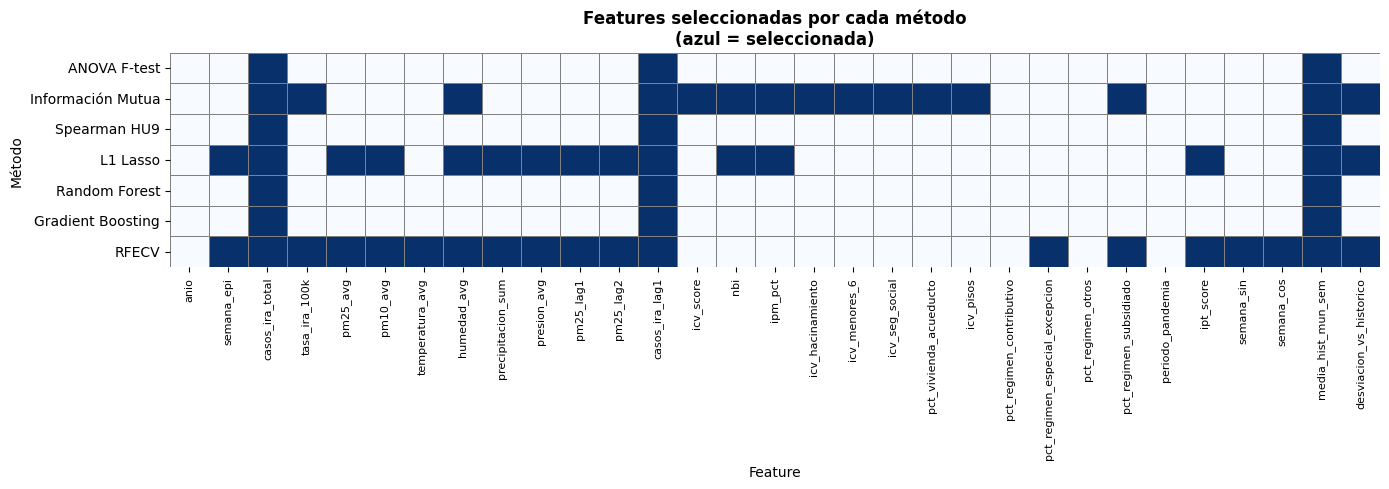

In [88]:
# ── Heatmap de cobertura de features por método ───────────
cobertura = pd.DataFrame(
    {metodo: {f: 1 if f in feats else 0
              for f in feature_names}
     for metodo, feats in feature_sets.items()
     if metodo != 'Todos los rasgos'},
    index=feature_names
).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cobertura, cmap='Blues', linewidths=0.5,
            linecolor='gray', ax=ax, cbar=False,
            xticklabels=True, yticklabels=True)
ax.set_title('Features seleccionadas por cada método\n(azul = seleccionada)',
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Método')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS / 'nb07_heatmap_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [89]:
# Selección final: features que aparecen en ≥ mitad de métodos
umbral_votos = n_metodos // 2
FEATURES_FINALES = estabilidad[
    estabilidad['Métodos que la seleccionan'] >= umbral_votos
]['Feature'].tolist()

# Siempre incluir las features más críticas validadas en HU9
FEATURES_CRITICAS = [
    'casos_ira_lag1', 'pm25_lag1', 'pm25_avg',
    'icv_seg_social', 'icv_score', 'ipm_pct',
    'media_hist_mun_sem', 'semana_sin', 'semana_cos'
]
for f in FEATURES_CRITICAS:
    if f in feature_names and f not in FEATURES_FINALES:
        FEATURES_FINALES.append(f)

print(f"Features seleccionadas para el modelo final: {len(FEATURES_FINALES)}")
print(FEATURES_FINALES)

Features seleccionadas para el modelo final: 12
['media_hist_mun_sem', 'casos_ira_total', 'casos_ira_lag1', 'humedad_avg', 'desviacion_vs_historico', 'pm25_lag1', 'pm25_avg', 'icv_seg_social', 'icv_score', 'ipm_pct', 'semana_sin', 'semana_cos']


In [90]:
# ── 6.6 Comparación PRE vs POST Feature Engineering ───────
# Siguiendo el método de clase: probar modelo antes y después del FE.

modelo_pre = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, random_state=42)
modelo_pre.fit(X_train[FEATURES_BASE].fillna(X_train[FEATURES_BASE].median()),
               y_train)
pred_pre = modelo_pre.predict(X_val[FEATURES_BASE].fillna(
    X_val[FEATURES_BASE].median()))
rmse_pre = np.sqrt(mean_squared_error(y_val, pred_pre))
mae_pre  = mean_absolute_error(y_val, pred_pre)

modelo_post = GradientBoostingRegressor(
    n_estimators=100, max_depth=4, random_state=42)
modelo_post.fit(
    X_train[FEATURES_FINALES].fillna(X_train[FEATURES_FINALES].median()),
    y_train)
pred_post = modelo_post.predict(
    X_val[FEATURES_FINALES].fillna(X_val[FEATURES_FINALES].median()))
rmse_post = np.sqrt(mean_squared_error(y_val, pred_post))
mae_post  = mean_absolute_error(y_val, pred_post)

In [91]:
print("=== PRE vs POST FEATURE ENGINEERING (Gradient Boosting en val) ===\n")
print(f"{'Métrica':<12} {'Baseline Naive':>16} {'Pre-FE':>10} {'Post-FE':>10}")
print("─" * 52)
print(f"{'RMSE':<12} {rmse_naive:>16.4f} {rmse_pre:>10.4f} {rmse_post:>10.4f}")
print(f"{'MAE':<12} {mae_naive:>16.4f} {mae_pre:>10.4f} {mae_post:>10.4f}")
print(f"\nMejora FE vs Pre-FE: {(rmse_pre-rmse_post)/rmse_pre*100:+.1f}% en RMSE")
print(f"Mejora Pre-FE vs Naive: {(rmse_naive-rmse_pre)/rmse_naive*100:+.1f}%")
print(f"Mejora Post-FE vs Naive: {(rmse_naive-rmse_post)/rmse_naive*100:+.1f}%")

=== PRE vs POST FEATURE ENGINEERING (Gradient Boosting en val) ===

Métrica        Baseline Naive     Pre-FE    Post-FE
────────────────────────────────────────────────────
RMSE                   2.0763     4.4557     3.5821
MAE                    1.0768     3.9102     2.9582

Mejora FE vs Pre-FE: +19.6% en RMSE
Mejora Pre-FE vs Naive: -114.6%
Mejora Post-FE vs Naive: -72.5%


## 7. Modelado — Entrenamiento XGBoost (HU13)

### 7.1 Comparación de modelos (igual que en clase)
### 7.2 Grid Search de hiperparámetros XGBoost
### 7.3 Modelo final y evaluación en test
### 7.4 Feature Importance
### 7.5 Análisis de residuales (igual que en clase)
### 7.6 Serialización del modelo

In [92]:
# ── 7.1 Comparación de modelos (estilo clase) ─────────────
# En el notebook de regresión de clase probaron múltiples modelos
# antes de elegir el mejor. Hacemos lo mismo para justificar XGBoost.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor

def entrenar_y_evaluar(nombre, modelo, X_tr, y_tr, X_v, y_v, feats):
    Xf_tr = X_tr[feats].fillna(X_tr[feats].median())
    Xf_v  = X_v[feats].fillna(X_v[feats].median())
    modelo.fit(Xf_tr, y_tr)
    pred  = modelo.predict(Xf_v)
    rmse  = np.sqrt(mean_squared_error(y_v, pred))
    mae   = mean_absolute_error(y_v, pred)
    r2    = r2_score(y_v, pred)
    print(f"  {nombre:<35} RMSE={rmse:.4f} MAE={mae:.4f} R²={r2:.4f}")
    return {'nombre': nombre, 'rmse': rmse, 'mae': mae, 'r2': r2, 'modelo': modelo}

In [93]:
print("=== COMPARACIÓN DE MODELOS EN VALIDACIÓN ===\n")
resultados_modelos = []

modelos_a_probar = [
    ('KNN Regressor',
     KNeighborsRegressor(n_neighbors=5)),
    ('Decision Tree',
     DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('Extra Trees',
     ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Random Forest',
     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('AdaBoost',
     AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('Gradient Boosting',
     GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)),
    ('XGBoost',
     xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                      tree_method='hist', random_state=42, verbosity=0)),
]

=== COMPARACIÓN DE MODELOS EN VALIDACIÓN ===



In [94]:
for nombre, modelo in modelos_a_probar:
    r = entrenar_y_evaluar(nombre, modelo, X_train, y_train,
                           X_val, y_val, FEATURES_FINALES)
    resultados_modelos.append(r)

df_modelos = pd.DataFrame([{k: v for k, v in r.items() if k != 'modelo'}
                            for r in resultados_modelos])
print(f"\n{'─'*60}")
print(f"Baseline Naive RMSE: {rmse_naive:.4f}")
print(f"\nMejor modelo: {df_modelos.loc[df_modelos['rmse'].idxmin(), 'nombre']}")
print(f"RMSE mínimo:  {df_modelos['rmse'].min():.4f}")

  KNN Regressor                       RMSE=3.7499 MAE=3.2755 R²=-0.9169
  Decision Tree                       RMSE=3.7608 MAE=2.9516 R²=-0.9280
  Extra Trees                         RMSE=3.4747 MAE=2.9334 R²=-0.6458
  Random Forest                       RMSE=3.7708 MAE=3.2098 R²=-0.9384
  AdaBoost                            RMSE=3.8693 MAE=3.3145 R²=-1.0409
  Gradient Boosting                   RMSE=3.5821 MAE=2.9582 R²=-0.7491
  XGBoost                             RMSE=3.8100 MAE=3.1419 R²=-0.9788

────────────────────────────────────────────────────────────
Baseline Naive RMSE: 2.0763

Mejor modelo: Extra Trees
RMSE mínimo:  3.4747


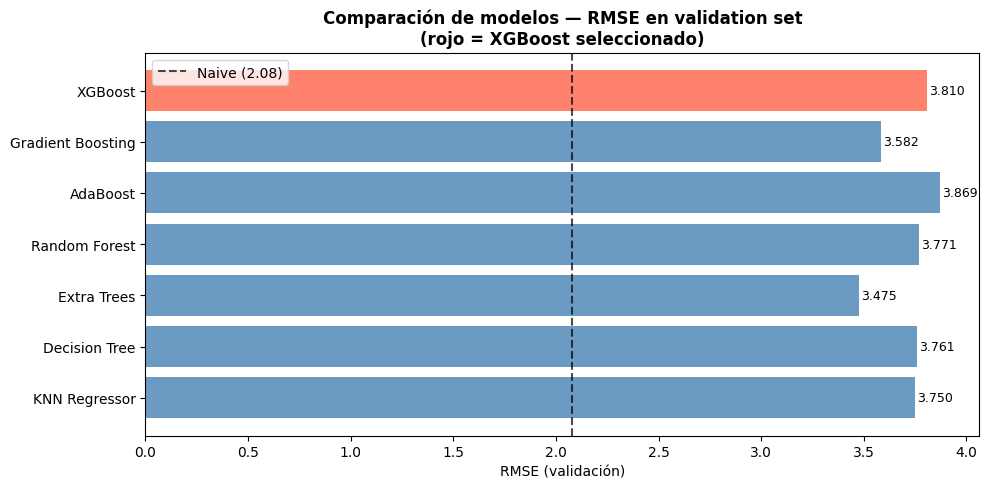

In [95]:
# ── Gráfico comparación de modelos ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
nombres = df_modelos['nombre']
rmses   = df_modelos['rmse']
colores = ['tomato' if n == 'XGBoost' else 'steelblue' for n in nombres]

bars = ax.barh(nombres, rmses, color=colores, alpha=0.8)
ax.axvline(x=rmse_naive, color='black', linestyle='--',
           alpha=0.7, label=f'Naive ({rmse_naive:.2f})')
ax.set_xlabel('RMSE (validación)')
ax.set_title('Comparación de modelos — RMSE en validation set\n(rojo = XGBoost seleccionado)',
             fontweight='bold')
ax.legend()
for bar, val in zip(bars, rmses):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS / 'nb07_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

In [96]:
# ── 7.2 Grid Search de hiperparámetros XGBoost ────────────
grid = {
    'max_depth':        [3, 4, 6],
    'learning_rate':    [0.05, 0.1, 0.15],
    'n_estimators':     [100, 200, 300],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

In [97]:
print("Búsqueda de hiperparámetros sobre X_val (puede tardar 2-3 min)...")
mejores_params = None
mejor_rmse_val = float('inf')
resultados_grid = []

feats_fill = lambda X: X[FEATURES_FINALES].fillna(X[FEATURES_FINALES].median())

for md, lr, ne, ss, cs in product(
        grid['max_depth'], grid['learning_rate'],
        grid['n_estimators'], grid['subsample'],
        grid['colsample_bytree']):
    m = xgb.XGBRegressor(
        max_depth=md, learning_rate=lr, n_estimators=ne,
        subsample=ss, colsample_bytree=cs,
        tree_method='hist', random_state=42, verbosity=0
    )
    m.fit(feats_fill(X_train), y_train, verbose=False)
    pred = m.predict(feats_fill(X_val))
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    resultados_grid.append({
        'max_depth': md, 'learning_rate': lr, 'n_estimators': ne,
        'subsample': ss, 'colsample_bytree': cs, 'rmse_val': rmse
    })
    if rmse < mejor_rmse_val:
        mejor_rmse_val = rmse
        mejores_params = {
            'max_depth': md, 'learning_rate': lr, 'n_estimators': ne,
            'subsample': ss, 'colsample_bytree': cs
        }

df_grid = pd.DataFrame(resultados_grid).sort_values('rmse_val')
print(f"\nMejor RMSE en validación: {mejor_rmse_val:.4f}")
print("Mejores hiperparámetros:")
for k, v in mejores_params.items():
    print(f"  {k}: {v}")
print(f"\nTop 5 combinaciones:")
print(df_grid.head(5).drop(columns='rmse_val').assign(
    rmse_val=df_grid.head(5)['rmse_val']).to_string(index=False))

Búsqueda de hiperparámetros sobre X_val (puede tardar 2-3 min)...

Mejor RMSE en validación: 3.5057
Mejores hiperparámetros:
  max_depth: 3
  learning_rate: 0.05
  n_estimators: 200
  subsample: 1.0
  colsample_bytree: 0.8

Top 5 combinaciones:
 max_depth  learning_rate  n_estimators  subsample  colsample_bytree  rmse_val
         3           0.05           200        1.0               0.8  3.505658
         3           0.05           300        1.0               0.8  3.512569
         3           0.05           100        1.0               0.8  3.538711
         3           0.10           300        1.0               0.8  3.567921
         3           0.10           100        1.0               0.8  3.576196


In [98]:
# ── 7.3 Modelo final y evaluación en test ─────────────────
# Entrena con train+val juntos (maximizar datos antes del test)
X_trainval = pd.concat([
    X_train[FEATURES_FINALES], X_val[FEATURES_FINALES]
]).fillna(pd.concat([X_train, X_val])[FEATURES_FINALES].median())
y_trainval = pd.concat([y_train, y_val])

modelo_final = xgb.XGBRegressor(
    **mejores_params, tree_method='hist',
    random_state=42, verbosity=0
)
modelo_final.fit(X_trainval, y_trainval)

pred_test = modelo_final.predict(
    X_test[FEATURES_FINALES].fillna(
        X_test[FEATURES_FINALES].median()))
pred_test = np.clip(pred_test, 0, None)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
mae_test  = mean_absolute_error(y_test, pred_test)
r2_test   = r2_score(y_test, pred_test)

In [99]:
print("=== RESULTADOS FINALES EN TEST (2022-2023) ===\n")
print(f"{'Métrica':<12} {'Baseline Naive':>16} {'XGBoost Final':>15}")
print("─" * 46)
print(f"{'RMSE':<12} {rmse_naive:>16.4f} {rmse_test:>15.4f}")
print(f"{'MAE':<12} {mae_naive:>16.4f} {mae_test:>15.4f}")
print(f"{'R²':<12} {'N/A':>16} {r2_test:>15.4f}")
print(f"\nMejora vs Naive: {(rmse_naive-rmse_test)/rmse_naive*100:+.1f}%")
print(f"Criterio HU14: {'✓ CUMPLIDO' if rmse_test < rmse_naive else '✗ FALLA — revisar modelo'}")

=== RESULTADOS FINALES EN TEST (2022-2023) ===

Métrica        Baseline Naive   XGBoost Final
──────────────────────────────────────────────
RMSE                   2.0763          1.7399
MAE                    1.0768          1.0295
R²                        N/A          0.6069

Mejora vs Naive: +16.2%
Criterio HU14: ✓ CUMPLIDO


In [100]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

# Evaluar XGBoost con CV temporal sobre train+val
X_tv = pd.concat([X_train, X_val])[FEATURES_FINALES].fillna(
    pd.concat([X_train, X_val])[FEATURES_FINALES].median())
y_tv = pd.concat([y_train, y_val])

scores = cross_val_score(
    xgb.XGBRegressor(**mejores_params, tree_method='hist',
                     random_state=42, verbosity=0),
    X_tv, y_tv,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rmse_cv = -scores
print(f"TimeSeriesSplit CV (5 folds):")
print(f"  RMSE por fold: {rmse_cv.round(4)}")
print(f"  RMSE medio:    {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}")
print(f"  Naive RMSE:    {rmse_naive:.4f}")
print(f"  Mejora media vs naive: {(rmse_naive-rmse_cv.mean())/rmse_naive*100:+.1f}%")

TimeSeriesSplit CV (5 folds):
  RMSE por fold: [4.4306 1.0329 1.1465 0.2886 2.6751]
  RMSE medio:    1.9147 ± 1.4778
  Naive RMSE:    2.0763
  Mejora media vs naive: +7.8%


=== FEATURE IMPORTANCE (XGBoost gain) ===
Esta tabla alimenta variable_causal en alertas_territoriales (HU15)

                feature  importance
         casos_ira_lag1    0.388103
        casos_ira_total    0.359781
         icv_seg_social    0.048498
     media_hist_mun_sem    0.047673
            humedad_avg    0.032424
             semana_sin    0.028462
             semana_cos    0.028387
desviacion_vs_historico    0.024752
              pm25_lag1    0.021714
               pm25_avg    0.018084
              icv_score    0.002121
                ipm_pct    0.000000


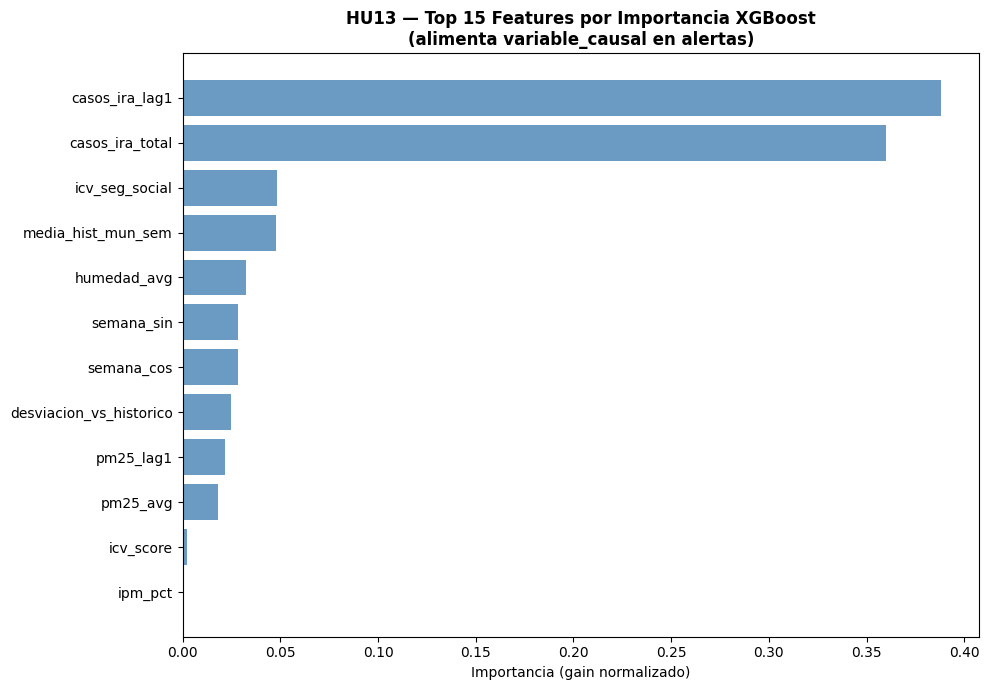

In [101]:
# ── 7.4 Feature Importance ────────────────────────────────
importancias = pd.DataFrame({
    'feature':    FEATURES_FINALES,
    'importance': modelo_final.feature_importances_
}).sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE (XGBoost gain) ===")
print("Esta tabla alimenta variable_causal en alertas_territoriales (HU15)\n")
print(importancias.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top = importancias.head(15)
ax.barh(top['feature'][::-1], top['importance'][::-1],
        color='steelblue', alpha=0.8)
ax.set_xlabel('Importancia (gain normalizado)')
ax.set_title('HU13 — Top 15 Features por Importancia XGBoost\n'
             '(alimenta variable_causal en alertas)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'nb07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

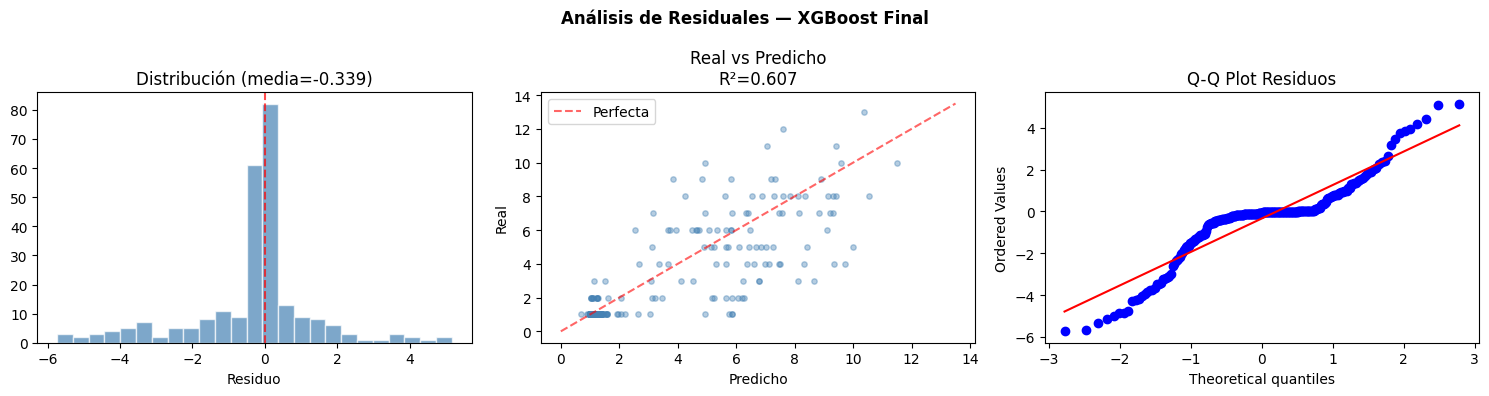

Shapiro-Wilk residuos: W=0.8658 p=0.0000 → NO normales


In [102]:
# ── 7.5 Análisis de residuales (igual que en clase) ───────
def analisis_residuales(y_real, y_pred, nombre_modelo):
    from scipy import stats
    y_r = np.asarray(y_real).ravel()
    y_p = np.asarray(y_pred).ravel()
    residuos = y_r - y_p

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Análisis de Residuales — {nombre_modelo}',
                 fontweight='bold')

    # Histograma de residuos
    axes[0].hist(residuos, bins=25, color='steelblue',
                 alpha=0.7, edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title(f'Distribución (media={residuos.mean():.3f})')
    axes[0].set_xlabel('Residuo')

    # Real vs Predicho
    axes[1].scatter(y_p, y_r, alpha=0.4, color='steelblue', s=15)
    lim = max(y_r.max(), y_p.max()) + 0.5
    axes[1].plot([0,lim],[0,lim],'r--', alpha=0.6, label='Perfecta')
    axes[1].set_xlabel('Predicho')
    axes[1].set_ylabel('Real')
    axes[1].set_title(f'Real vs Predicho\nR²={r2_score(y_r,y_p):.3f}')
    axes[1].legend()

    # Q-Q plot de residuos
    stats.probplot(residuos, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot Residuos')

    plt.tight_layout()
    plt.savefig(PLOTS / f'nb07_residuales_{nombre_modelo.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    stat, p = stats.shapiro(residuos[:min(500, len(residuos))])
    print(f"Shapiro-Wilk residuos: W={stat:.4f} p={p:.4f} "
          f"→ {'NO normales' if p < 0.05 else 'Normales'}")

analisis_residuales(y_test, pred_test, 'XGBoost Final')

In [103]:
# ── 7.6 Serialización del modelo ──────────────────────────
ruta_modelo = MODELS / "modelo_xgboost_vitalrisk.pkl"
artefacto = {
    'modelo':          modelo_final,
    'features':        FEATURES_FINALES,
    'mejores_params':  mejores_params,
    'fill_values':     X_trainval.median().to_dict(),
    'metricas_test': {
        'rmse': float(rmse_test), 'mae': float(mae_test),
        'r2': float(r2_test),
        'rmse_naive': float(rmse_naive),
        'mejora_vs_naive_pct': float((rmse_naive-rmse_test)/rmse_naive*100)
    },
    'split': {'train':'2018-2020','val':'2021','test':'2022-2023'},
    'feature_importance': importancias.set_index('feature')['importance'].to_dict()
}
with open(ruta_modelo, 'wb') as f:
    pickle.dump(artefacto, f)

with open(MODELS / "metricas_modelo.json", 'w') as f:
    json.dump({k: v for k, v in artefacto.items()
               if k not in ['modelo','fill_values']},
              f, indent=2, ensure_ascii=False)


In [104]:
print(f"✓ Modelo serializado: {ruta_modelo}")
print(f"✓ Métricas: {MODELS}/metricas_modelo.json")
print(f"\nResumen HU13:")
print(f"  RMSE test:    {rmse_test:.4f}")
print(f"  MAE test:     {mae_test:.4f}")
print(f"  R² test:      {r2_test:.4f}")
print(f"  Mejora naive: {(rmse_naive-rmse_test)/rmse_naive*100:+.1f}%")
print(f"  Features:     {len(FEATURES_FINALES)}")
print(f"  Modelo .pkl:  {ruta_modelo.stat().st_size/1024:.1f} KB")

✓ Modelo serializado: ..\data\models\modelo_xgboost_vitalrisk.pkl
✓ Métricas: ..\data\models/metricas_modelo.json

Resumen HU13:
  RMSE test:    1.7399
  MAE test:     1.0295
  R² test:      0.6069
  Mejora naive: +16.2%
  Features:     12
  Modelo .pkl:  233.6 KB


In [105]:
# Agregar al diccionario del artefacto antes de serializar
artefacto['cv_temporal'] = {
    'rmse_por_fold': rmse_cv.tolist(),
    'rmse_medio':    float(rmse_cv.mean()),
    'rmse_std':      float(rmse_cv.std()),
    'mejora_vs_naive_pct': float((rmse_naive - rmse_cv.mean()) / rmse_naive * 100),
    'interpretacion': (
        'Alta varianza entre folds es esperada en datos epidemiológicos '
        'con cambios de régimen (pandemia). RMSE test 2022-2023 es la '
        'métrica más representativa para producción post-pandemia.'
    )
}

# Re-serializar con el CV incluido
with open(MODELS / "modelo_xgboost_vitalrisk.pkl", 'wb') as f:
    pickle.dump(artefacto, f)
with open(MODELS / "metricas_modelo.json", 'w') as f:
    json.dump({k: v for k, v in artefacto.items()
               if k not in ['modelo', 'fill_values']},
              f, indent=2, ensure_ascii=False)
print("✓ Artefacto actualizado con CV temporal")

✓ Artefacto actualizado con CV temporal
